In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Loading in the combined datasets
sold = pd.read_csv('CRMLSSold_Combined.csv', low_memory=False)
listings = pd.read_csv('CRMLSListing_Combined.csv', low_memory=False)

In [2]:
print("Sold date range:", sold['CloseDate'].min(), "to", sold['CloseDate'].max())
print("Listings date range:", listings['ListingContractDate'].min(), "to", listings['ListingContractDate'].max())

Sold date range: 2024-01-01 to 2026-03-31
Listings date range: 2024-01-01 to 2026-03-31


## **Weeks 2–3 – Dataset Structuring and Validation**

### Dataset Understanding
1.  Identify number of rows and columns
2.  Review column data types
3.  Separate market analysis fields from metadata fields

In [3]:
# 1.  Identify number of rows and columns
print("Sold has", sold.shape[0], " rows and ", sold.shape[1], " columns.")
print("Listings has", listings.shape[0], " rows and ", listings.shape[1], " columns.")

Sold has 405008  rows and  82  columns.
Listings has 442925  rows and  73  columns.


In [4]:
# 2.  Review column data types
print(sold.dtypes.to_string())

BuyerAgentAOR                    object
ListAgentAOR                     object
Flooring                         object
ViewYN                           object
WaterfrontYN                     object
BasementYN                       object
PoolPrivateYN                    object
OriginalListPrice               float64
ListingKey                        int64
CloseDate                        object
ClosePrice                      float64
ListAgentFirstName               object
ListAgentLastName                object
Latitude                        float64
Longitude                       float64
UnparsedAddress                  object
PropertyType                     object
LivingArea                      float64
ListPrice                       float64
DaysOnMarket                      int64
ListOfficeName                   object
BuyerOfficeName                  object
CoListOfficeName                 object
ListAgentFullName                object
CoListAgentFirstName             object


In [5]:
# 3. Separate market analysis fields from metadata fields

market_fields = [
    # Prices
    'ClosePrice', 'ListPrice', 'OriginalListPrice',
    # Property details
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt',
    'LotSizeAcres', 'LotSizeSquareFeet', 'LotSizeArea', 'PropertySubType',
    # Time
    'CloseDate', 'ListingContractDate', 'PurchaseContractDate',
    'ContractStatusChangeDate', 'DaysOnMarket',
    # Location
    'City', 'CountyOrParish', 'PostalCode', 'StateOrProvince',
    'Latitude', 'Longitude', 'UnparsedAddress', 'MLSAreaMajor',
    # Property characteristics
    'PropertyType', 'MlsStatus', 'YearBuilt', 'GarageSpaces',
    'FireplaceYN', 'PoolPrivateYN', 'NewConstructionYN', 'Stories',
    'AssociationFee', 'AssociationFeeFrequency', 'ParkingTotal',
    # Agent & office (for competitive intelligence)
    'ListOfficeName', 'BuyerOfficeName', 'ListAgentFullName',
    'ListAgentFirstName', 'ListAgentLastName',
    'BuyerAgentFirstName', 'BuyerAgentLastName',
]

metadata_fields = [
    # System identifiers
    'ListingKey', 'ListingKeyNumeric', 'ListingId',
    # MLS system info
    'OriginatingSystemName', 'OriginatingSystemSubName',
    # Internal agent IDs
    'BuyerAgentMlsId', 'ListAgentAOR', 'BuyerAgentAOR', 'BuyerOfficeAOR',
    # Tax records (also 100% missing)
    'TaxYear', 'TaxAnnualAmount',
]

print(f"Market analysis fields: {len(market_fields)}")
print(f"Metadata fields: {len(metadata_fields)}")

Market analysis fields: 42
Metadata fields: 11


### Missing Value Analysis
1. Calculate missing counts and percentages per column
2. Flag columns with >90% missing values
3. Decide which columns to drop vs. retain (keep core fields even if partially missing)

In [6]:
# 1.  Calculate missing counts and percentages per column

# Creating a dataframe with missing count and percentage.
missing = pd.DataFrame({
    'missing_count': sold.isnull().sum(),                                   # adds all null rows to get the missing count.
    'missing_pct': (sold.isnull().sum() / len(sold) * 100).round(2)         # uses converts missing_count into a percentage of the total.
})

# Sorting by highest missing first.
missing = missing.sort_values('missing_pct', ascending=False)
missing.head(10)

,missing_count,missing_pct
MiddleOrJuniorSchoolDistrict,405008,100.00
BusinessType,405008,100.00
FireplacesTotal,405008,100.00
AboveGradeFinishedArea,405008,100.00
CoveredSpaces,405008,100.00
TaxAnnualAmount,405008,100.00
TaxYear,405008,100.00
ElementarySchoolDistrict,405008,100.00
WaterfrontYN,404755,99.94
BelowGradeFinishedArea,402658,99.42


In [7]:
# 2. Flag columns above 90% missing values.

high_missing = missing[missing['missing_pct'] > 90]
print(high_missing.shape[0], "columns are missing more than 90% of data:")
high_missing

15 columns are missing more than 90% of data:


,missing_count,missing_pct
MiddleOrJuniorSchoolDistrict,405008,100.00
BusinessType,405008,100.00
FireplacesTotal,405008,100.00
AboveGradeFinishedArea,405008,100.00
CoveredSpaces,405008,100.00
TaxAnnualAmount,405008,100.00
TaxYear,405008,100.00
ElementarySchoolDistrict,405008,100.00
WaterfrontYN,404755,99.94
BelowGradeFinishedArea,402658,99.42


In [8]:
# 3. Decide which columns to drop vs. retain.

# These 15 columns are >90% missing and carry no analytical value
columns_to_drop = high_missing.index.tolist()

# Note: columns will not be dropped yet.

### Numeric Distribution Review
For the following key numeric fields (ClosePrice, ListPrice, OriginalListPrice, LivingArea, LotSizeAcres, BedroomsTotal BathroomsTotalInteger, DaysOnMarket, and YearBuilt):
1. Generate a percentile summary
2. Create Histograms & Boxplots
3. Identify extreme outliers for later handling 

In [9]:
# 1. Generate a percentile summary
numeric_fields = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 
                  'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 
                  'DaysOnMarket', 'YearBuilt']

print(sold[numeric_fields].describe(percentiles=[.10, .25, .50, .75, .90, .95, .99]).to_string())

         ClosePrice     ListPrice  OriginalListPrice    LivingArea  LotSizeAcres  BedroomsTotal  BathroomsTotalInteger   DaysOnMarket      YearBuilt
count  4.050080e+05  4.050080e+05       4.041830e+05  4.047630e+05  3.726480e+05  404997.000000          404939.000000  405008.000000  404638.000000
mean   1.118686e+06  1.121940e+06       1.204617e+06  1.899823e+03  6.798610e+01       3.195310               2.529549      37.672350    1978.813505
std    1.409586e+06  1.348360e+06       6.635289e+06  2.677064e+04  1.618718e+04       1.069385               1.131640      53.718321      26.371992
min    5.250000e+02  5.250000e+02       0.000000e+00  0.000000e+00  0.000000e+00       0.000000               0.000000    -288.000000    1776.000000
10%    4.150000e+05  4.150000e+05       4.249000e+05  9.800000e+02  6.120000e-02       2.000000               1.000000       4.000000    1947.000000
25%    5.700000e+05  5.750000e+05       5.799990e+05  1.244000e+03  1.200000e-01       3.000000           

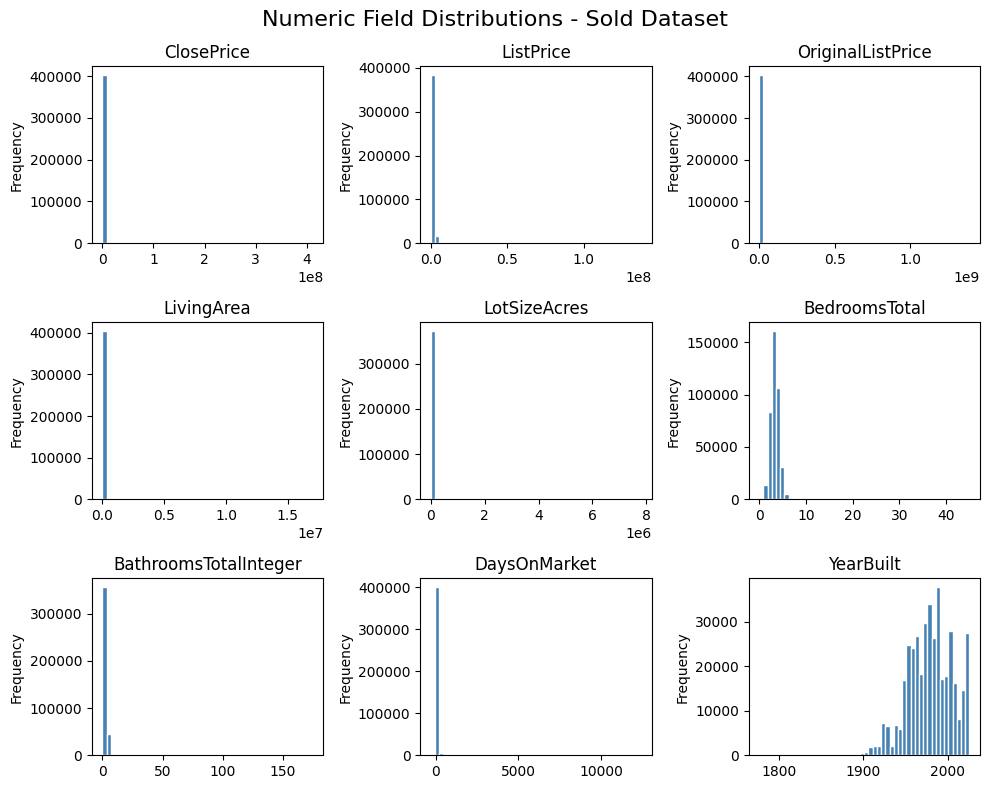

In [10]:
# 2a. Create Histograms & Boxplots

fig, axes = plt.subplots(3, 3, figsize=(10, 8))
fig.suptitle('Numeric Field Distributions - Sold Dataset', fontsize=16)

fields = ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
          'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger',
          'DaysOnMarket', 'YearBuilt']

for i, field in enumerate(fields):
    ax = axes[i//3, i%3]
    sold[field].dropna().plot(kind='hist', bins=50, ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(field)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

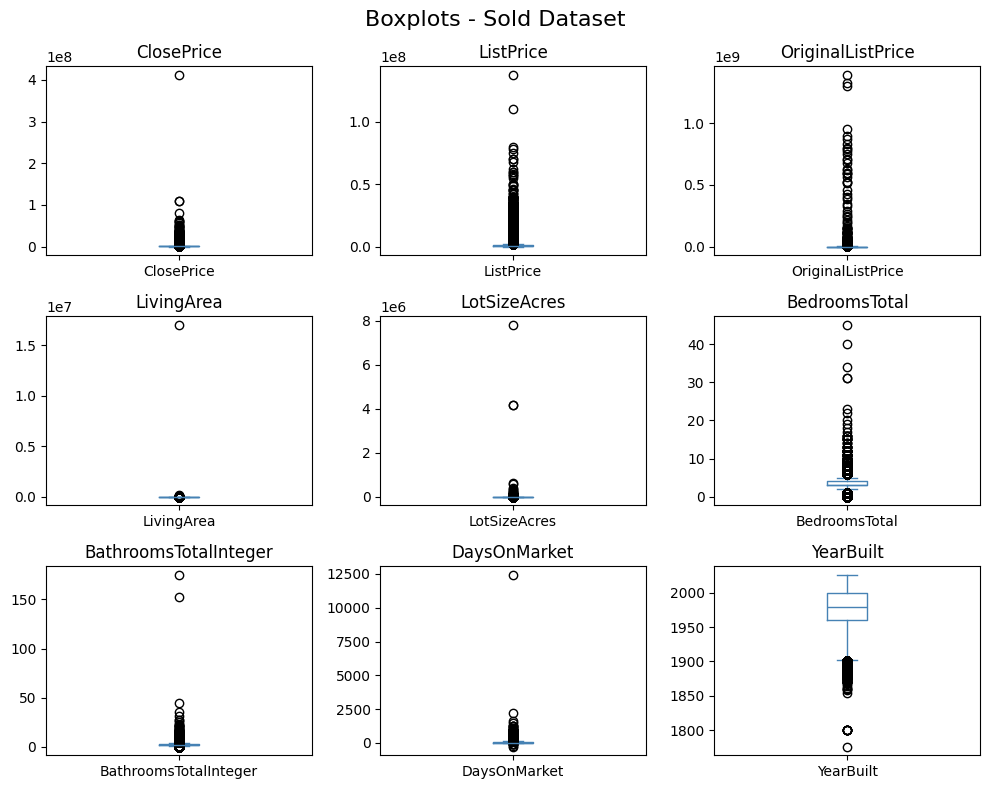

In [11]:
# 2b. Create Histograms & Boxplots
fig, axes = plt.subplots(3, 3, figsize=(10, 8))
fig.suptitle('Boxplots - Sold Dataset', fontsize=16)

for i, field in enumerate(numeric_fields):
    ax = axes[i//3, i%3]
    sold[field].dropna().plot(kind='box', ax=ax, color='steelblue')
    ax.set_title(field)

plt.tight_layout()
plt.show()

In [12]:
# 3. Identify extreme outliers for later handling 

# Using IQR method
# Previewing outlier boundaries based on percentile analysis

print("Extreme outliers in key numeric fields:")
for field in numeric_fields:
    Q1 = sold[field].quantile(0.25)
    Q3 = sold[field].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = ((sold[field] < lower) | (sold[field] > upper)).sum()
    print(f"{field:<25} {outlier_count:>7,} outliers | normal range {lower:>12,.0f} to {upper:>12,.0f}")

Extreme outliers in key numeric fields:
ClosePrice                 29,676 outliers | normal range     -487,500 to    2,332,500
ListPrice                  31,318 outliers | normal range     -449,500 to    2,282,500
OriginalListPrice          30,097 outliers | normal range     -482,752 to    2,351,252
LivingArea                 17,780 outliers | normal range         -210 to        3,666
LotSizeAcres               57,954 outliers | normal range           -0 to            1
BedroomsTotal              22,371 outliers | normal range            2 to            6
BathroomsTotalInteger      18,394 outliers | normal range            0 to            4
DaysOnMarket               30,132 outliers | normal range          -54 to          110
YearBuilt                     945 outliers | normal range        1,902 to        2,058


### Answering Suggested Intern Questions

**What is the Residential vs. other property type share?**

In [13]:
sample = pd.read_csv('CRMLSSold202603.csv', low_memory=False)
print("Property type breakdown (sample from March 2026):")
print(sample['PropertyType'].value_counts())
print(f"\nResidential share: {sample['PropertyType'].value_counts(normalize=True).get('Residential', 0)*100:.1f}%")

Property type breakdown (sample from March 2026):
PropertyType
Residential            15756
ResidentialLease        5527
Land                     781
ManufacturedInPark       649
ResidentialIncome        570
CommercialSale           146
CommercialLease          112
BusinessOpportunity       11
Name: count, dtype: int64

Residential share: 66.9%


**What are the median and average close prices?**

In [14]:
print(f"Median close price: ${sold['ClosePrice'].median():,.0f}")
print(f"Average close price: ${sold['ClosePrice'].mean():,.0f}")

Median close price: $810,000
Average close price: $1,118,686


**Which counties have the highest median prices?**

In [15]:
print("\nTop 10 counties by median close price:")
print(sold.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False).head(10).apply(lambda x: f"${x:,.0f}"))


Top 10 counties by median close price:
CountyOrParish
Del Norte        $6,742,500
San Mateo        $1,650,000
Santa Clara      $1,540,000
Santa Cruz       $1,181,000
Orange           $1,170,000
San Francisco    $1,162,500
Marin            $1,152,500
Alameda          $1,120,000
Alpine           $1,100,000
Mono             $1,030,000
Name: ClosePrice, dtype: object


**What percentage of homes sold above vs. below list price?**

In [16]:
sold['sold_above_list'] = sold['ClosePrice'] >= sold['ListPrice']
pct_above = sold['sold_above_list'].mean() * 100
print(f"\nHomes sold at or above list price: {pct_above:.1f}%")
print(f"Homes sold below list price: {100 - pct_above:.1f}%")


Homes sold at or above list price: 57.2%
Homes sold below list price: 42.8%


**What does the Days on Market distribution look like?**

In [17]:
print("Days on Market summary:")
print(f"  Median: {sold['DaysOnMarket'].median():.0f} days")
print(f"  Average: {sold['DaysOnMarket'].mean():.1f} days")
print(f"  Negative values (bad data): {(sold['DaysOnMarket'] < 0).sum()}")
print(f"  Over 365 days: {(sold['DaysOnMarket'] > 365).sum()}")

Days on Market summary:
  Median: 19 days
  Average: 37.7 days
  Negative values (bad data): 44
  Over 365 days: 760


**Are there any apparent date consistency issues (e.g., close date before listing date)?**

In [18]:
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'])
sold['ListingContractDate'] = pd.to_datetime(sold['ListingContractDate'])
sold['PurchaseContractDate'] = pd.to_datetime(sold['PurchaseContractDate'])

print(f"\nDate consistency issues:")
print(f"  Close date before listing date: {(sold['CloseDate'] < sold['ListingContractDate']).sum()}")
print(f"  Close date before purchase contract date: {(sold['CloseDate'] < sold['PurchaseContractDate']).sum()}")



Date consistency issues:
  Close date before listing date: 71
  Close date before purchase contract date: 92
